SHAP XAI Layer 

In [1]:
import os
import sys

project_root=os.path.abspath(os.path.join(os.getcwd(),'..'))
sys.path.append(project_root)

print(f"Project root: {project_root}")

Project root: c:\Users\aryap\Desktop\predictive_maintenance


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import warnings
import joblib
import shap

warnings.filterwarnings('ignore')

# Initialize SHAP JavaScript visualizations
shap.initjs()

print(f" Libraries imported")
print(f"   SHAP version : {shap.__version__}")

 Libraries imported
   SHAP version : 0.49.1


Load engineered data

In [3]:
data_path=os.path.join(project_root,'data','engineered_data.csv')
df=pd.read_csv(data_path)

feature_columns=[
    'air_temperature',
    'process_temperature',
    'rotational_speed',
    'torque',
    'tool_wear',
    'temp_diff',
    'power',
    'tool_wear_torque',
    'type_encoded'
]

class_names={
    0: 'No Failure',
    1: 'HDF',
    2: 'OSF',
    3: 'PWF',
    4: 'TWF',
    5: 'RNF'
}

X = df[feature_columns]
y_rul   = df['rul']
y_class = df['failure_mode_encoded']

print(f"Data loaded")
print(f"   Shape : {df.shape}")

Data loaded
   Shape : (10000, 13)


Loading both saved models

In [4]:
# Load Random Forest Regressor
regressor_path  = os.path.join(project_root, 'models', 'rf_regressor.pkl')
rf_regressor    = joblib.load(regressor_path)

# Load Random Forest Classifier
classifier_path = os.path.join(project_root, 'models', 'rf_classifier.pkl')
rf_classifier   = joblib.load(classifier_path)

print(f"Models loaded successfully")
print(f"   Regressor  : {type(rf_regressor).__name__}")
print(f"   Classifier : {type(rf_classifier).__name__}")

Models loaded successfully
   Regressor  : RandomForestRegressor
   Classifier : RandomForestClassifier


Background sample for SHAP

In [5]:
# SHAP TreeExplainer works best with a background sample
# We use 500 random records as the background distribution
# This is what SHAP uses to compute the baseline (expected value)

np.random.seed(42)
background_idx     = np.random.choice(len(X), size=500, replace=False)
X_background       = X.iloc[background_idx]

# Also prepare a small explanation set — 100 records
# Running SHAP on all 10,000 records is slow
# 100 records gives us accurate global patterns quickly
explain_idx        = np.random.choice(len(X), size=100, replace=False)
X_explain          = X.iloc[explain_idx]

print(f" SHAP sample sets prepared")
print(f"   Background sample : {X_background.shape[0]} records")
print(f"   Explanation set   : {X_explain.shape[0]} records")

 SHAP sample sets prepared
   Background sample : 500 records
   Explanation set   : 100 records


SHAP for RUL Regressor

In [8]:
# SHAP TREE EXPLAINER — REGRESSOR
# TreeExplainer is optimised specifically
# for tree-based models like Random Forest
# Much faster than model-agnostic explainers

print("Creating SHAP explainer for regressor:")

explainer_reg=shap.TreeExplainer(
    rf_regressor,
    data    = X_background,
    feature_perturbation = "interventional"
)

print("  Computed SHAP values for explanation set")
shap_values_reg = explainer_reg.shap_values(X_explain)

print(f" SHAP values computed")
print(f"   Shape of SHAP values : {shap_values_reg.shape}")
print(f"   Expected value (baseline RUL) : {explainer_reg.expected_value:.2f} minutes")

Creating SHAP explainer for regressor:
  Computed SHAP values for explanation set
 SHAP values computed
   Shape of SHAP values : (100, 9)
   Expected value (baseline RUL) : 136.15 minutes


Global SHAP summary plot

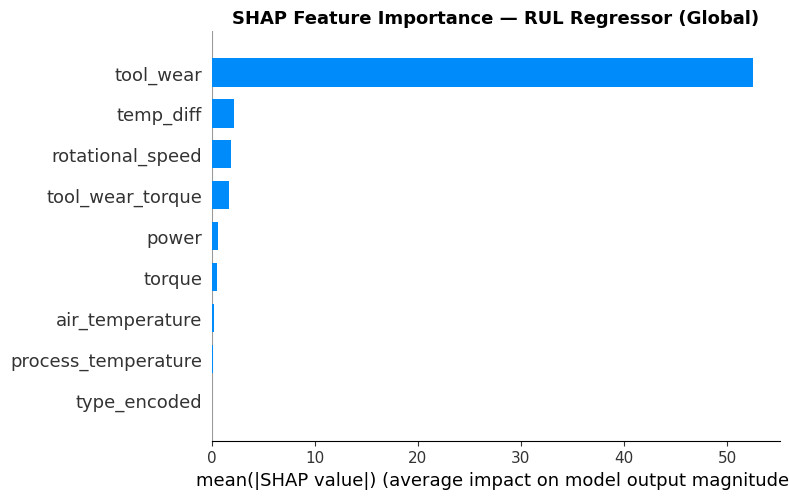

In [9]:
plt.figure()

shap.summary_plot(
    shap_values_reg,
    X_explain,
    feature_names = feature_columns,
    plot_type     = "bar",
    show          = False
)

plt.title("SHAP Feature Importance — RUL Regressor (Global)",
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/shap_reg_global_bar.png', dpi=150, bbox_inches='tight')
plt.show()


BEESWARM PLOT

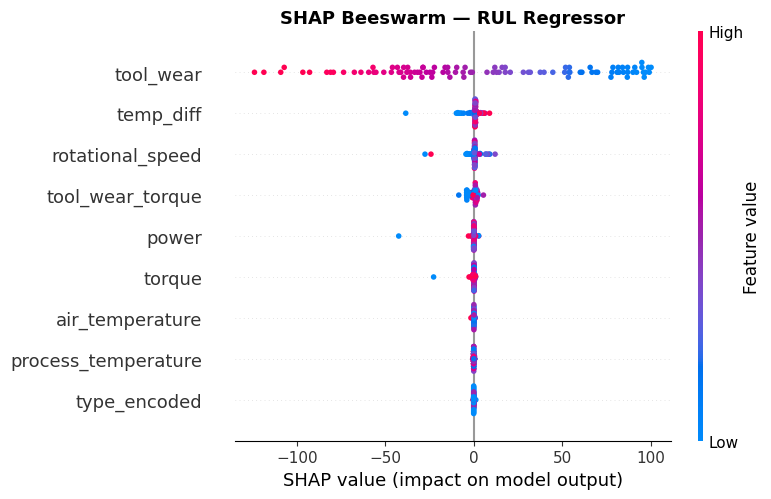

In [10]:
plt.figure()

shap.summary_plot(
    shap_values_reg,
    X_explain,
    feature_names = feature_columns,
    plot_type     = "dot",
    show          = False
)

plt.title("SHAP Beeswarm — RUL Regressor",
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/shap_reg_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()


Waterfall plot for single prediction (local explanation)

In [11]:
#picking a record with low RUL (high risk) so that the explanation is meaningful
# low RUL - near maintenance zone
low_rul_mask=df['rul']<40
low_rul_idx=df[low_rul_mask].index.tolist()

#pick first one that's in the explanation set
sample_idx=None
for idx in low_rul_idx:
    if idx in explain_idx:
        sample_idx=idx
        break

# pick lowest RUL in explanation set
if sample_idx is None:
    sample_idx=df.iloc[explain_idx]['rul'].idxmin()

sample_record=X.loc[[sample_idx]]
actual_rul=df.loc[sample_idx,'rul']
predicted_rul=rf_regressor.predict(sample_record)[0]
failure_mode=df.loc[sample_idx,'failure_mode']

print("Sample record selected:")
print(f"Index: {sample_idx}")
print(f"Actual RUL     : {actual_rul:.0f} minutes")
print(f"Predicted RUL  : {predicted_rul:.2f} minutes")
print(f"Failure Mode   : {failure_mode}")
print(f"\nSensor readings:")
for col in feature_columns:
    print(f"   {col:<25} : {sample_record[col].values[0]:.3f}")

Sample record selected:
Index: 1087
Actual RUL     : 0 minutes
Predicted RUL  : 31.27 minutes
Failure Mode   : TWF

Sensor readings:
   air_temperature           : 296.900
   process_temperature       : 307.800
   rotational_speed          : 1549.000
   torque                    : 35.800
   tool_wear                 : 206.000
   temp_diff                 : 10.900
   power                     : 5807.150
   tool_wear_torque          : 7374.800
   type_encoded              : 2.000


Waterfall plot

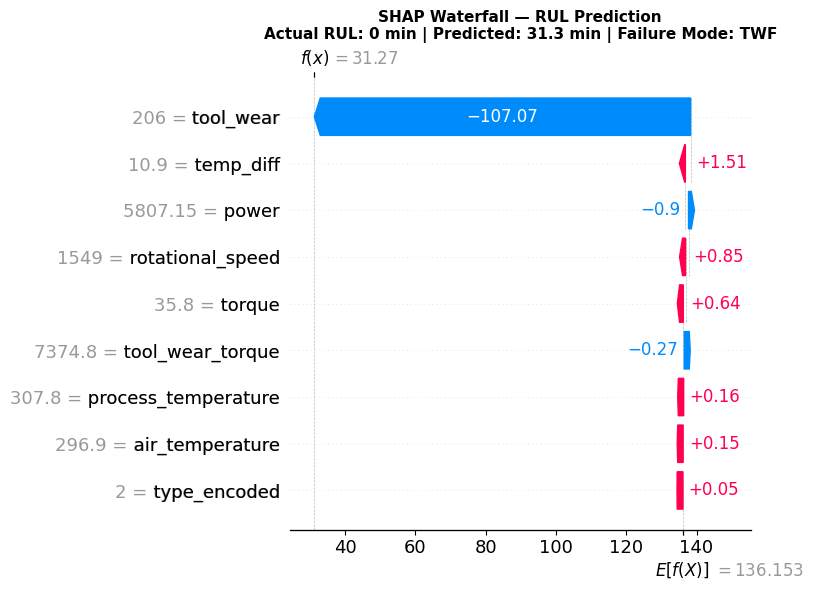

In [12]:
# Compute SHAP values for this single record
shap_single = explainer_reg.shap_values(sample_record)

# Build SHAP Explanation object for waterfall plot
explanation = shap.Explanation(
    values        = shap_single[0],
    base_values   = explainer_reg.expected_value,
    data          = sample_record.values[0],
    feature_names = feature_columns
)

plt.figure(figsize=(10, 6))

shap.waterfall_plot(
    explanation,
    show = False
)

plt.title(
    f"SHAP Waterfall — RUL Prediction\n"
    f"Actual RUL: {actual_rul:.0f} min | "
    f"Predicted: {predicted_rul:.1f} min | "
    f"Failure Mode: {failure_mode}",
    fontsize=11, fontweight='bold'
)

plt.tight_layout()
plt.savefig('../notebooks/shap_reg_waterfall.png',
            dpi=150, bbox_inches='tight')
plt.show()



Programmatic interpretation of waterfall plot

In [14]:
# Build a readable interpretation of the waterfall
shap_df = pd.DataFrame({
    'Feature'   : feature_columns,
    'Value'     : sample_record.values[0],
    'SHAP'      : shap_single[0]
}).sort_values('SHAP', key=abs, ascending=False)

print(f"SHAP Explanation — What drove this RUL prediction?")
print(f"   Baseline RUL (average): {explainer_reg.expected_value:.2f} min")
print(f"   Final prediction      : {predicted_rul:.2f} min")
print(f"   Actual RUL            : {actual_rul:.0f} min")
print()
print(f"{'Feature':<25} {'Value':>10} {'SHAP':>10} {'Direction'}")
print("-" * 60)

for _, row in shap_df.iterrows():
    direction = "↑ pushes RUL UP  " if row['SHAP'] > 0 else "↓ pushes RUL DOWN"
    print(f"{row['Feature']:<25} {row['Value']:>10.3f} "
          f"{row['SHAP']:>10.3f}  {direction}")

print("-" * 60)
print(f"\nBaseline {explainer_reg.expected_value:.2f} + "
      f"sum of SHAP {shap_single[0].sum():.2f} = "
      f"{explainer_reg.expected_value + shap_single[0].sum():.2f} min predicted")

SHAP Explanation — What drove this RUL prediction?
   Baseline RUL (average): 136.15 min
   Final prediction      : 31.27 min
   Actual RUL            : 0 min

Feature                        Value       SHAP Direction
------------------------------------------------------------
tool_wear                    206.000   -107.065  ↓ pushes RUL DOWN
temp_diff                     10.900      1.508  ↑ pushes RUL UP  
power                       5807.150     -0.901  ↓ pushes RUL DOWN
rotational_speed            1549.000      0.846  ↑ pushes RUL UP  
torque                        35.800      0.637  ↑ pushes RUL UP  
tool_wear_torque            7374.800     -0.270  ↓ pushes RUL DOWN
process_temperature          307.800      0.163  ↑ pushes RUL UP  
air_temperature              296.900      0.152  ↑ pushes RUL UP  
type_encoded                   2.000      0.048  ↑ pushes RUL UP  
------------------------------------------------------------

Baseline 136.15 + sum of SHAP -104.88 = 31.27 min predic

SHAP for failure mode classifier

In [17]:
# SHAP TREE EXPLAINER — CLASSIFIER
# For multi-class classification SHAP returns
# one set of SHAP values per class
# Shape: (n_samples, n_features, n_classes)


print("Creating SHAP explainer for classifier...")

explainer_clf = shap.TreeExplainer(
    rf_classifier,
    data                 = X_background,
    feature_perturbation = "interventional"
)

print(" Computing SHAP values for explanation set...")
shap_values_clf = explainer_clf.shap_values(X_explain)

print(f" SHAP values computed")
print(f"   Number of classes        : {len(shap_values_clf)}")
print(f"   Shape per class          : {shap_values_clf[0].shape}")
print(f"   Expected values (baseline probabilities):")
for i, (cls, name) in enumerate(class_names.items()):
    print(f"   Class {cls} — {name:<15} : {explainer_clf.expected_value[i]:.4f}")

Creating SHAP explainer for classifier...
 Computing SHAP values for explanation set...


100%|===================| 598/600 [00:16<00:00]        

 SHAP values computed
   Number of classes        : 100
   Shape per class          : (9, 6)
   Expected values (baseline probabilities):
   Class 0 — No Failure      : 0.9544
   Class 1 — HDF             : 0.0202
   Class 2 — OSF             : 0.0100
   Class 3 — PWF             : 0.0000
   Class 4 — TWF             : 0.0063
   Class 5 — RNF             : 0.0091


Global SHAP summary per failure mode

SHAP format: 3D array (new format)
SHAP values normalized
   Number of classes : 6
   Shape per class   : (100, 9)


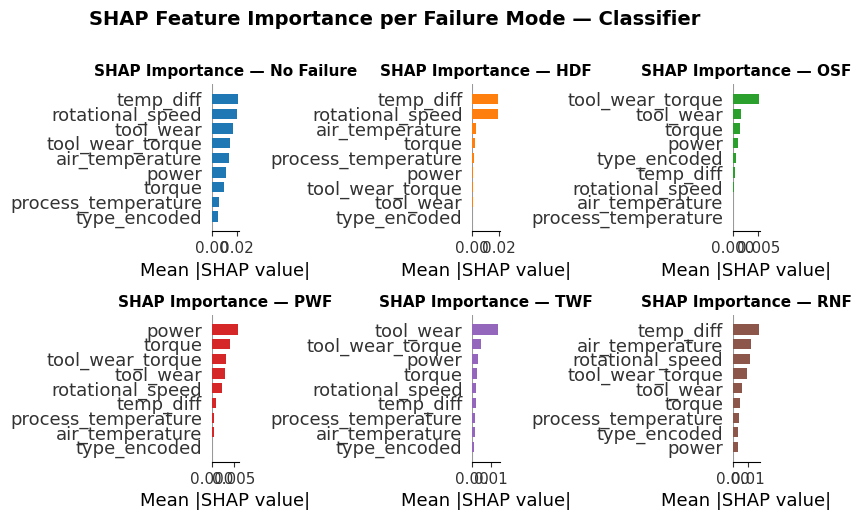

In [22]:
# Fix for newer SHAP versions
# shap_values_clf may be a 3D array (n_samples, n_features, n_classes)
# instead of a list of 2D arrays

# Detect SHAP values format and normalize
if isinstance(shap_values_clf, list):
    # Old format — list of arrays, one per class
    shap_per_class = shap_values_clf
    print("SHAP format: list of arrays (old format)")
else:
    # New format — single 3D array
    # Shape: (n_samples, n_features, n_classes)
    shap_per_class = [shap_values_clf[:, :, i]
                      for i in range(len(class_names))]
    print("SHAP format: 3D array (new format)")

print(f"SHAP values normalized")
print(f"   Number of classes : {len(shap_per_class)}")
print(f"   Shape per class   : {shap_per_class[0].shape}")

# Now plot
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes      = axes.flatten()

for i, (cls, name) in enumerate(class_names.items()):
    plt.sca(axes[i])

    shap.summary_plot(
        shap_per_class[i],
        X_explain,
        feature_names = feature_columns,
        plot_type     = "bar",
        show          = False,
        color         = plt.cm.tab10(i)
    )

    axes[i].set_title(f'SHAP Importance — {name}',
                      fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Mean |SHAP value|')

plt.suptitle('SHAP Feature Importance per Failure Mode — Classifier',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../notebooks/shap_clf_global_per_class.png',
            dpi=150, bbox_inches='tight')
plt.show()


Picking a Failure record for local explanation

In [24]:
# Picking a record that the classifier predicts as a failure

# Find records where classifier predicts a non-zero class
X_explain_df      = X_explain.copy()
predicted_classes = rf_classifier.predict(X_explain_df)
predicted_probas  = rf_classifier.predict_proba(X_explain_df)

# Find first record predicted as failure (not No Failure)
failure_mask = predicted_classes != 0
failure_positions = np.where(failure_mask)[0]

if len(failure_positions) > 0:
    pos          = failure_positions[0]
    sample_pos   = pos
else:
    # Fallback — pick record with lowest No Failure probability
    sample_pos   = np.argmin(predicted_probas[:, 0])

sample_record_clf  = X_explain_df.iloc[[sample_pos]]
actual_class       = df['failure_mode'].iloc[explain_idx[sample_pos]]
predicted_class    = class_names[predicted_classes[sample_pos]]
actual_rul_clf     = df['rul'].iloc[explain_idx[sample_pos]]

print(f" Sample Record Selected for Classifier Explanation:")
print(f"   Position in explain set : {sample_pos}")
print(f"   Actual failure mode     : {actual_class}")
print(f"   Predicted failure mode  : {predicted_class}")
print(f"   Actual RUL              : {actual_rul_clf:.0f} minutes")
print(f"\n   Predicted probabilities:")
for cls, name in class_names.items():
    prob = predicted_probas[sample_pos][cls]
    bar  = '█' * int(prob * 30)
    print(f"   {name:<15} : {prob:.4f}  {bar}")

 Sample Record Selected for Classifier Explanation:
   Position in explain set : 16
   Actual failure mode     : PWF
   Predicted failure mode  : PWF
   Actual RUL              : 0 minutes

   Predicted probabilities:
   No Failure      : 0.0000  
   HDF             : 0.0000  
   OSF             : 0.0000  
   PWF             : 1.0000  ██████████████████████████████
   TWF             : 0.0000  
   RNF             : 0.0000  


Waterfall plot for predicted failure class

✅ SHAP values extracted per class
   Predicted class index : 3
   Predicted class name  : PWF
   SHAP values shape     : (9,)


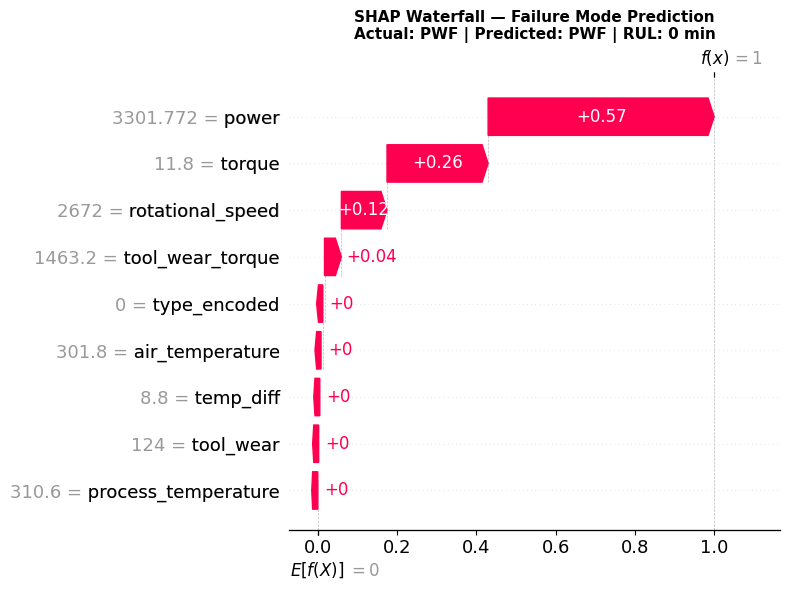

In [26]:
# ─────────────────────────────────────────
# WATERFALL PLOT FOR CLASSIFIER
# Fixed for SHAP 0.49.x 3D array format
# ─────────────────────────────────────────

# Compute SHAP values for this single record
shap_single_clf = explainer_clf.shap_values(sample_record_clf)

# Normalize to per-class list regardless of SHAP version
if isinstance(shap_single_clf, list):
    # Old format — list of arrays
    shap_single_per_class = [shap_single_clf[i][0]
                              for i in range(len(class_names))]
    expected_values = explainer_clf.expected_value
else:
    # New format — 3D array (n_samples, n_features, n_classes)
    shap_single_per_class = [shap_single_clf[0, :, i]
                              for i in range(len(class_names))]
    # Expected value may also be array or single value
    if hasattr(explainer_clf.expected_value, '__len__'):
        expected_values = explainer_clf.expected_value
    else:
        expected_values = [explainer_clf.expected_value] * len(class_names)

print(f"✅ SHAP values extracted per class")
print(f"   Predicted class index : {pred_class_idx}")
print(f"   Predicted class name  : {class_names[pred_class_idx]}")
print(f"   SHAP values shape     : {shap_single_per_class[pred_class_idx].shape}")

# Build explanation for predicted class
explanation_clf = shap.Explanation(
    values        = shap_single_per_class[pred_class_idx],
    base_values   = expected_values[pred_class_idx],
    data          = sample_record_clf.values[0],
    feature_names = feature_columns
)

plt.figure(figsize=(10, 6))

shap.waterfall_plot(
    explanation_clf,
    show = False
)

plt.title(
    f"SHAP Waterfall — Failure Mode Prediction\n"
    f"Actual: {actual_class} | "
    f"Predicted: {predicted_class} | "
    f"RUL: {actual_rul_clf:.0f} min",
    fontsize=11, fontweight='bold'
)

plt.tight_layout()
plt.savefig('../notebooks/shap_clf_waterfall.png',
            dpi=150, bbox_inches='tight')
plt.show()


Feature importance comparison chart

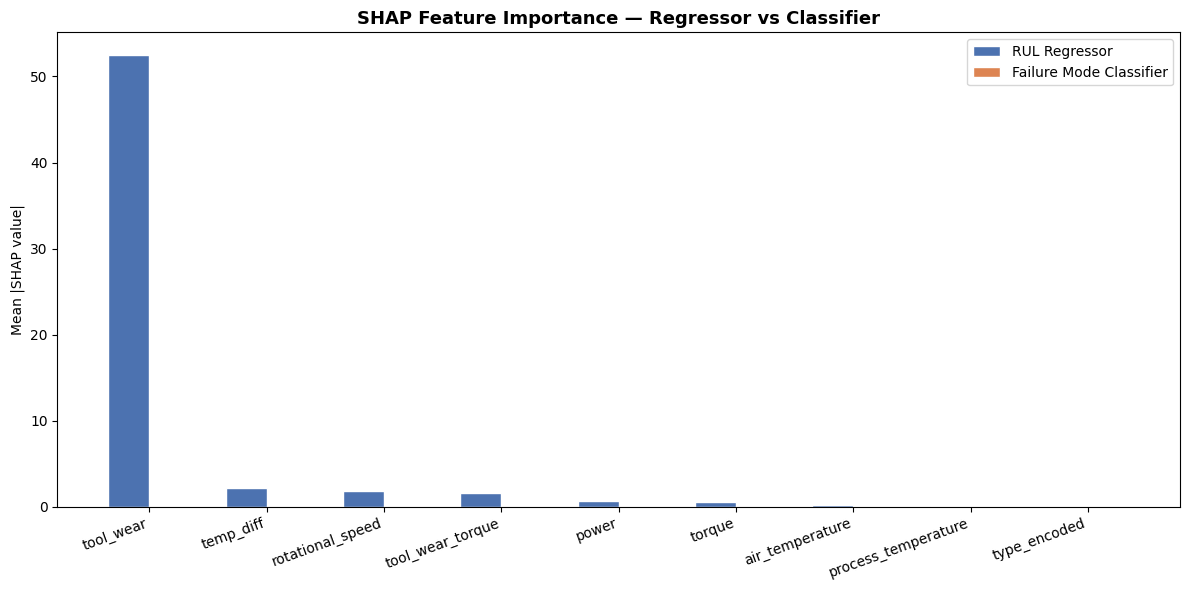

In [28]:
# Global mean absolute SHAP for regressor
reg_importance = pd.DataFrame({
    'Feature'   : feature_columns,
    'Regressor' : np.abs(shap_values_reg).mean(axis=0)
})

# Global mean absolute SHAP for classifier
# Use shap_per_class which was already normalized in Cell 13
clf_importance_all = np.mean(
    [np.abs(shap_per_class[i]).mean(axis=0)
     for i in range(len(class_names))],
    axis=0
)

clf_importance = pd.DataFrame({
    'Feature'    : feature_columns,
    'Classifier' : clf_importance_all
})

combined = reg_importance.merge(clf_importance, on='Feature')
combined = combined.sort_values('Regressor', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))

x     = np.arange(len(feature_columns))
width = 0.35

bars1 = ax.bar(x - width/2,
               combined['Regressor'],
               width,
               label     = 'RUL Regressor',
               color     = '#4C72B0',
               edgecolor = 'white')

bars2 = ax.bar(x + width/2,
               combined['Classifier'],
               width,
               label     = 'Failure Mode Classifier',
               color     = '#DD8452',
               edgecolor = 'white')

ax.set_title('SHAP Feature Importance — Regressor vs Classifier',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(combined['Feature'], rotation=20, ha='right')
ax.set_ylabel('Mean |SHAP value|')
ax.legend()
plt.tight_layout()
plt.savefig('../notebooks/shap_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
